# 선형 회귀

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

* 모든 설치가 끝나면 한글 폰트를 바르게 출력하기 위해 **[런타임]** -> **[런타임 다시시작]**을 클릭한 다음, 아래 셀부터 코드를 실행해 주십시오.

In [1]:
# 라이브러리 임포트

%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchviz import make_dot

In [3]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [4]:
# device 설정 코드
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## 5.3 선형 함수(nn.Linear)

###  입력 :1 출력 :1인 선형 함수

In [5]:
# 코드 5-1: 선형 함수의 인스턴스 생성
# 입력이 2차원, 출력이 3차원인 선형 함수를 정의합니다.
l = nn.Linear(2, 3)
print(l)
# w1x1 + w2x2 + b

Linear(in_features=2, out_features=3, bias=True)


In [6]:
# 코드 5-2 & 5-3: 1입력 1출력 선형 함수 생성 및 내부 파라미터 확인

# 난수 시드값 고정 (항상 동일한 결과를 얻기 위함)
torch.manual_seed(123)

# 입력: 1, 출력: 1 선형 함수를 정의합니다.
# y = w1x1 + b
l1 = nn.Linear(1, 1)

# 생성된 선형 함수를 확인합니다.
print("l1 정보:")
print(l1)

l1 정보:
Linear(in_features=1, out_features=1, bias=True)


In [ ]:
# l1 내부의 파라미터(weight, bias)를 확인합니다.
print("\nl1의 파라미터:")
for param in l1.named_parameters():
    print('name  :', param[0])       # 파라미터 이름 출력
    print('tensor:', param[1])       # 파라미터 텐서 값 출력
    print('shape :', param[1].shape) # 파라미터 텐서의 모양 출력


l1의 파라미터:
name  : weight
tensor: Parameter containing:
tensor([[-0.4078]], requires_grad=True)
shape : torch.Size([1, 1])
name  : bias
tensor: Parameter containing:
tensor([0.0331], requires_grad=True)
shape : torch.Size([1])


In [7]:
# 코드 5-4: 레이어 함수 안의 파라미터 초깃값 설정

# 초깃값 설정 (weight=2.0, bias=1.0)
nn.init.constant_(l1.weight, 2.0) # weight 텐서의 모든 값을 2.0으로 설정
nn.init.constant_(l1.bias, 1.0)   # bias 텐서의 모든 값을 1.0으로 설정

# 결과 확인
print("weight:", l1.weight)
print("bias:", l1.bias)

weight: Parameter containing:
tensor([[2.]], requires_grad=True)
bias: Parameter containing:
tensor([1.], requires_grad=True)


In [8]:
np.arange(-2.0, 2.1, 1.0)

array([-2., -1.,  0.,  1.,  2.])

In [9]:
# 코드 5-5: 테스트용 변수 준비

# -2부터 2까지 1씩 증가하는 NumPy 배열 생성
x_np = np.arange(-2.0, 2.1, 1.0)
print(x_np)
# NumPy 배열을 PyTorch 텐서로 변환
x = torch.tensor(x_np).float() # .float()으로 데이터 타입을 float32로 지정
print(x)

# (N, 1) 사이즈로 변경. N은 데이터 개수.
# 선형 함수는 기본적으로 배치(묶음) 데이터를 처리하므로 2차원 텐서 입력을 가정합니다.
x = x.view(-1, 1)  # (5,1)
print(x)

# 결과 확인
print("x의 shape:", x.shape)
print("x의 값:\n", x)

[-2. -1.  0.  1.  2.]
tensor([-2., -1.,  0.,  1.,  2.])
tensor([[-2.],
        [-1.],
        [ 0.],
        [ 1.],
        [ 2.]])
x의 shape: torch.Size([5, 1])
x의 값:
 tensor([[-2.],
        [-1.],
        [ 0.],
        [ 1.],
        [ 2.]])


In [10]:
# 코드 5-6: 1차 함수 테스트

# l1 함수에 x를 입력하여 y를 계산합니다.
y = l1(x)
print(y)
# 결과 확인
print("y의 shape:", y.shape)
print("y의 data:\n", y.data) # y.data는 requires_grad 정보 없이 순수 데이터만 보여줍니다.

tensor([[-3.],
        [-1.],
        [ 1.],
        [ 3.],
        [ 5.]], grad_fn=<AddmmBackward0>)
y의 shape: torch.Size([5, 1])
y의 data:
 tensor([[-3.],
        [-1.],
        [ 1.],
        [ 3.],
        [ 5.]])


### 입력 :2 출력 :1인 선형 함수

In [11]:
# 코드 5-7: 2입력 1출력 선형 함수 정의 및 초기화

# 입력: 2, 출력: 1 선형 함수 정의
l2 = nn.Linear(2, 1)

# 초깃값 설정 (모든 가중치는 1.0, 편향은 2.0으로 설정)
nn.init.constant_(l2.weight, 1.0)
nn.init.constant_(l2.bias, 2.0)

# y = w1x1 + w2x2 + b >> y = 1 x1 + 1 x2 + 2
# 결과 확인
print("weight:", l2.weight)
print("bias:", l2.bias)

weight: Parameter containing:
tensor([[1., 1.]], requires_grad=True)
bias: Parameter containing:
tensor([2.], requires_grad=True)


In [12]:
# 코드 5-8 & 5-9: 2입력 1출력 함수 테스트

# 테스트용 2차원 데이터 준비
x2_np = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
x2 = torch.tensor(x2_np).float()

print("x2의 shape:", x2.shape)
print("x2의 값:\n", x2)

x2의 shape: torch.Size([4, 2])
x2의 값:
 tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])


In [13]:
# 함수 값 계산
y2 = l2(x2)

# shape 확인
print(y2.shape)

# 값 확인
print(y2.data)

torch.Size([4, 1])
tensor([[2.],
        [3.],
        [3.],
        [4.]])


### 입력 :2 출력:3인 선형 함수

In [14]:
# 코드 5-10: 2입력 3출력 선형 함수 정의 및 초기화

# 입력: 2, 출력: 3 선형 함수 정의
l3 = nn.Linear(2, 3)

# 초깃값 설정 (weight 행렬의 각 행을 다른 값으로 설정)
nn.init.constant_(l3.weight[0, :], 1.0)
nn.init.constant_(l3.weight[1, :], 2.0)
nn.init.constant_(l3.weight[2, :], 3.0)
nn.init.constant_(l3.bias, 2.0)

# 결과 확인
print("weight:", l3.weight)
print("bias:", l3.bias)

weight: Parameter containing:
tensor([[1., 1.],
        [2., 2.],
        [3., 3.]], requires_grad=True)
bias: Parameter containing:
tensor([2., 2., 2.], requires_grad=True)


In [15]:
# 코드 5-11: 2입력 3출력 함수 테스트

# 함수 값 계산 (입력은 x2를 재사용)
y3 = l3(x2)

# 결과 확인
print("y3의 shape:", y3.shape)
print("y3의 data:\n", y3.data)

y3의 shape: torch.Size([4, 3])
y3의 data:
 tensor([[2., 2., 2.],
        [3., 4., 5.],
        [3., 4., 5.],
        [4., 6., 8.]])


## 5.4 커스텀 클래스를 이용한 모델 정의

In [23]:
# 코드 5-12 모델을 정의하는 본질적인 부분
class Net(nn.Module): # 모든 모델의 부모 클래스인 nn.Module을 상속받습니다.
    def __init__(self, n_input, n_output):
        # 부모 클래스 nn.Module의 초기화 메서드를 반드시 호출해야 합니다.
        super().__init__()

        # 출력층 정의: 입력 특성 수(n_input)와 출력 특성 수(n_output)를 받는 선형 레이어(l1)를 정의합니다.
        self.l1 = nn.Linear(n_input, n_output)

    # 예측 함수 정의: 데이터의 순전파 흐름을 정의합니다.
    def forward(self, x):
        x1 = self.l1(x) # __init__에서 정의한 선형 레이어에 입력 x를 통과시킵니다.
        return x1

In [17]:
torch.ones(100, 1)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
      

In [24]:
# 코드 5-13 커스텀 클래스를 활용한 예측

# 더미 입력 데이터 생성 (100개의 샘플, 1개의 특성)
inputs = torch.ones(100, 1)
# print(inputs)
# 인스턴스 생성 (1 입력, 1 출력 선형 모델)
n_input = 1
n_output = 1
net = Net(n_input, n_output) # Net 클래스의 인스턴스를 생성합니다.

# 예측 수행
# net 인스턴스를 함수처럼 호출하면, 내부적으로 forward 메서드가 실행됩니다.
outputs = net(inputs)

print(outputs.shape)
# 처음 5개 예측값 출력
print(outputs[:5])

torch.Size([100, 1])
tensor([[-0.1081],
        [-0.1081],
        [-0.1081],
        [-0.1081],
        [-0.1081]], grad_fn=<SliceBackward0>)


In [25]:
torch.zeros(100, 1)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
      

In [26]:
# 코드 5-14 손실 함수의 정의(초기화 처리에 포함)

# 손실 함수 정의: 평균 제곱 오차(Mean Square Error)
criterion = nn.MSELoss()

# 코드 5-15 손실 함수의 호출(반복 처리에 포함)

# 예측값(outputs)은 위에서 생성한 값을 사용하고, 정답(labels) 텐서를 임의로 생성합니다.
labels1 = torch.zeros(100, 1) # 정답이 모두 0이라고 가정
# print(labels1)
# 손실 계산
loss = criterion(outputs, labels1)

# 경사 계산
loss.backward()

print(f"계산된 손실(loss): {loss.item()}")
# l1 레이어의 가중치에 대한 경사(gradient) 값 확인
print(f"l1.weight.grad: {net.l1.weight.grad}")

계산된 손실(loss): 0.011679695919156075
l1.weight.grad: tensor([[-0.2161]])


In [27]:
# 코드 5-16 손실(loss)의 계산 방법

# 1. 예측 계산 (첫 번째 함수)
outputs = net(inputs)
# print(outputs)
# 2. 손실 계산 (두 번째 함수)
loss = criterion(outputs, labels1)

print(f"합성 함수 결과(loss): {loss.item()}")

합성 함수 결과(loss): 0.011679695919156075



## 5.6 데이터 준비
UCI 공개 데이터셋 중에서 회귀 문제에 자주 사용되는 '보스턴 데이터셋'을 사용한다.

https://www.cs.toronto.edu/~delve/data/boston/bostonDetail.html

원본 데이터셋은, 17개 항목의 입력값으로부터 부동산 가격을 예측하기 위함이지만, 가장 단순한 '단일 회귀 모델'(1입력)을 만든다면 이 항목중에서 ``RM``이라는 항목만을 추출한다.


In [30]:
# 학습용 데이터셋 준비

# '보스턴 데이터셋'은 현재 사이킷런 라이브러리에서 가져올 수 있지만,
# 사이킷런에서 앞으로 이 데이터를 사용할 수 없기 때문에 웹 url에서 직접 수집

data_url = "http://lib.stat.cmu.edu/datasets/boston"
# 원본 데이터
raw_df = pd.read_csv(data_url, sep="\s+",
                     skiprows=22, header=None)

# print(raw_df)
x_org = np.hstack([raw_df.values[::2, :],
                   raw_df.values[1::2, :2]])
# print(x_org)
yt = raw_df.values[1::2, 2]
# print(yt)
feature_names = np.array(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX',
                          'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO','B', 'LSTAT'])

# 결과 확인
print('원본 데이터', x_org.shape, yt.shape)
print('항목명: ', feature_names)

<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_24667/2478662075.py:8: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+",


원본 데이터 (506, 13) (506,)
항목명:  ['CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX' 'PTRATIO'
 'B' 'LSTAT']


In [ ]:
x_org

array([[  0.0063,  18.    ,   2.31  , ...,  15.3   , 396.9   ,   4.98  ],
       [  0.0273,   0.    ,   7.07  , ...,  17.8   , 396.9   ,   9.14  ],
       [  0.0273,   0.    ,   7.07  , ...,  17.8   , 392.83  ,   4.03  ],
       ...,
       [  0.0608,   0.    ,  11.93  , ...,  21.    , 396.9   ,   5.64  ],
       [  0.1096,   0.    ,  11.93  , ...,  21.    , 393.45  ,   6.48  ],
       [  0.0474,   0.    ,  11.93  , ...,  21.    , 396.9   ,   7.88  ]])

In [31]:
# 코드 5-18: 입력 데이터 추출

# 데이터 추출(RM 항목)
x = x_org[:, feature_names == 'RM'] # RM 특성만 선택하여 x에 저장
# print(x)
print('추출 후', x.shape)
print(x[:5, :])

# 정답 데이터 표시
print('정답 데이터')
print(yt[:5])

추출 후 (506, 1)
[[6.575]
 [6.421]
 [7.185]
 [6.998]
 [7.147]]
정답 데이터
[24.  21.6 34.7 33.4 36.2]


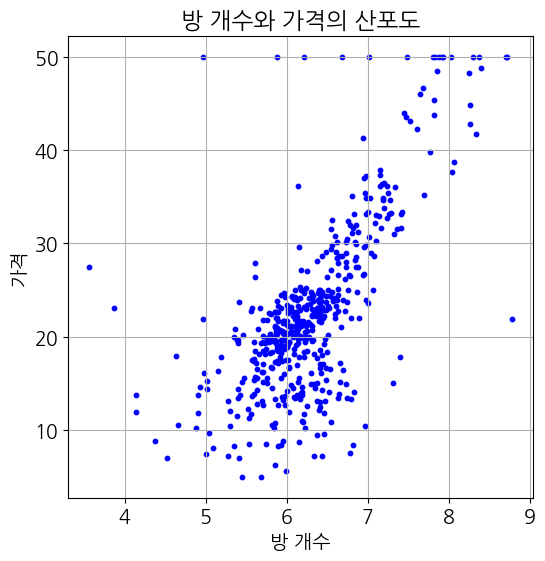

In [ ]:
# 코드 5-19: 산포도 출력

# 산포도 출력
plt.scatter(x, yt, s=10, c='b') # x축은 방 개수, y축은 가격
plt.xlabel('방 개수')
plt.ylabel('가격')
plt.title('방 개수와 가격의 산포도')
plt.grid(True)
plt.show()

## 5.7 모델 정의

In [32]:
x

array([[6.575],
       [6.421],
       [7.185],
       [6.998],
       [7.147],
       [6.43 ],
       [6.012],
       [6.172],
       [5.631],
       [6.004],
       [6.377],
       [6.009],
       [5.889],
       [5.949],
       [6.096],
       [5.834],
       [5.935],
       [5.99 ],
       [5.456],
       [5.727],
       [5.57 ],
       [5.965],
       [6.142],
       [5.813],
       [5.924],
       [5.599],
       [5.813],
       [6.047],
       [6.495],
       [6.674],
       [5.713],
       [6.072],
       [5.95 ],
       [5.701],
       [6.096],
       [5.933],
       [5.841],
       [5.85 ],
       [5.966],
       [6.595],
       [7.024],
       [6.77 ],
       [6.169],
       [6.211],
       [6.069],
       [5.682],
       [5.786],
       [6.03 ],
       [5.399],
       [5.602],
       [5.963],
       [6.115],
       [6.511],
       [5.998],
       [5.888],
       [7.249],
       [6.383],
       [6.816],
       [6.145],
       [5.927],
       [5.741],
       [5.966],
       [

In [33]:
x.shape

(506, 1)

In [34]:
x.shape[1]

1

In [35]:
# 코드 5-20: 변수 정의

# 입력 차원수 (특성이 1개: RM)
n_input = x.shape[1]
# 출력 차원수 (예측할 값 1개: Price)
n_output = 1

print(f'입력 차원수: {n_input} 출력 차원수: {n_output}')

입력 차원수: 1 출력 차원수: 1


In [ ]:
# 코드 5-21: 머신러닝 모델(예측 모델)의 클래스 정의

# 머신러닝 모델(예측 모델)의 클래스 정의
class Net(nn.Module):
    def __init__(self, n_input, n_output): # 모델의 구조를 정의
        # 부모 클래스 nn.Module의 초기화 호출
        super().__init__()
        # 출력층 정의: 입력 차원에서 출력 차원으로 가는 선형 변환
        self.l1 = nn.Linear(n_input, n_output)

        # 초깃값을 모두 1로 설정
        nn.init.constant_(self.l1.weight, 1.0)
        nn.init.constant_(self.l1.bias, 1.0)

    # 예측 함수 정의
    def forward(self, x): # 데이터가 모델을 통과하는 흐름을 정의
        x1 = self.l1(x) # 선형 회귀 계산
        return x1

꿀팁 : 에러 없이 CPU, GPU 둘 다 사용하는 방법

- device 설정

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

- Model 정의
model = model.to(device)

- input을 gpu도 호환되게 맞추어줌

inputs = inputs.to(device)

labels=labels.view(-1, feature).to(device)

[여기서 잠깐]

plt 또는 연산하게 될 경우 >> .cpu().numpy()

In [36]:
# 코드 5-22: 인스턴스 생성

# 인스턴스 생성
# 1입력 1출력 선형 모델(모델에 device 설정해줌)
net = Net(n_input, n_output).to(device)

In [37]:
# 코드 5-23: 모델 안의 파라미터 목록 표시

# 모델 안의 파라미터를 확인
# 모델 안의 변수를 가져오기 위해 named_parameters 함수를 사용함
# 첫번째 요소는 변수명, 두번째 요소가 변숫값
for parameter in net.named_parameters():
    print(f'변수명: {parameter[0]}')
    print(f'변숫값: {parameter[1].data}')

변수명: l1.weight
변숫값: tensor([[-0.2358]], device='cuda:0')
변수명: l1.bias
변숫값: tensor([0.3210], device='cuda:0')


In [38]:
# 코드 5-24: parameters 함수의 사용 예

# 파라미터의 리스트를 가져오기 위해 parameters 함수를 사용
for parameter in net.parameters():
    print(parameter)

Parameter containing:
tensor([[-0.2358]], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([0.3210], device='cuda:0', requires_grad=True)


### 모델 확인

In [39]:
# 코드 5-25: 모델의 개요 표시 1

print(net)

Net(
  (l1): Linear(in_features=1, out_features=1, bias=True)
)


In [40]:
# 코드 5-26: 모델의 개요 표시 2

# torchinfo 라이브러리를 사용하면 더 상세한 정보 확인 가능
from torchinfo import summary

summary(net, (1,))
# (1,) : 입력 텐서의 shape
# (batch_size, 1)
# 이미지 (MNIST) (1, 28, 28) CHW 1:채널(흑백)
# 컬러이미지 (3, 28, 28) 3: RGB

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       2
Total params: 2
Trainable params: 2
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

### 손실 함수와 최적화 함수

In [41]:
# 코드 5-27: 손실 함수와 최적화 함수 정의

# 손실 함수: 평균 제곱 오차(Mean Squared Error)
criterion = nn.MSELoss()

# 학습률
lr = 0.01

# 최적화 함수: 확률적 경사 하강법(Stochastic Gradient Descent)
# net.parameters() : 파라미터 조정(파라미터: 학습대상, w,b)
optimizer = optim.SGD(net.parameters(), lr=lr)

In [ ]:
# SGD : 확률적 경사하강법(가장 기본적인 최적화 방법) 매번 전체 데이터 기울기 사용
# AdamW: Adaptive , moment, weight : 학습률을 적응적으로 조정. 빠르면서도 수치적으로 안정됨

## 5.8 경사 하강법

In [42]:
# 코드 5-28: 입력값 x와 정답 yt의 텐서 변수화

# 입력값 x와 정답 yt의 텐서 변수화
inputs = torch.tensor(x).float().to(device)
labels = torch.tensor(yt).float()

# 차원 수 확인
print(inputs.shape)
print(labels.shape)

torch.Size([506, 1])
torch.Size([506])


In [43]:
labels

tensor([24.0000, 21.6000, 34.7000, 33.4000, 36.2000, 28.7000, 22.9000, 27.1000,
        16.5000, 18.9000, 15.0000, 18.9000, 21.7000, 20.4000, 18.2000, 19.9000,
        23.1000, 17.5000, 20.2000, 18.2000, 13.6000, 19.6000, 15.2000, 14.5000,
        15.6000, 13.9000, 16.6000, 14.8000, 18.4000, 21.0000, 12.7000, 14.5000,
        13.2000, 13.1000, 13.5000, 18.9000, 20.0000, 21.0000, 24.7000, 30.8000,
        34.9000, 26.6000, 25.3000, 24.7000, 21.2000, 19.3000, 20.0000, 16.6000,
        14.4000, 19.4000, 19.7000, 20.5000, 25.0000, 23.4000, 18.9000, 35.4000,
        24.7000, 31.6000, 23.3000, 19.6000, 18.7000, 16.0000, 22.2000, 25.0000,
        33.0000, 23.5000, 19.4000, 22.0000, 17.4000, 20.9000, 24.2000, 21.7000,
        22.8000, 23.4000, 24.1000, 21.4000, 20.0000, 20.8000, 21.2000, 20.3000,
        28.0000, 23.9000, 24.8000, 22.9000, 23.9000, 26.6000, 22.5000, 22.2000,
        23.6000, 28.7000, 22.6000, 22.0000, 22.9000, 25.0000, 20.6000, 28.4000,
        21.4000, 38.7000, 43.8000, 33.20

In [44]:
# 코드 5-29: 정답 labels를 (N, 1) 차원 행렬로 변형

# 손실 계산을 위해 labels를 (N, 1) 차원의 행렬로 변환
labels1 = labels.view((-1, 1)).to(device)

# 차원 수 확인
print(labels1.shape)

torch.Size([506, 1])


In [46]:
# 코드 5-30: 예측 계산

# 예측 계산
outputs = net(inputs)
# print(outputs) # 모델의 예측값 >> y_hat(y_pred)

tensor([[-1.2296],
        [-1.1933],
        [-1.3735],
        [-1.3294],
        [-1.3645],
        [-1.1954],
        [-1.0968],
        [-1.1346],
        [-1.0070],
        [-1.0949],
        [-1.1829],
        [-1.0961],
        [-1.0678],
        [-1.0820],
        [-1.1166],
        [-1.0549],
        [-1.0787],
        [-1.0916],
        [-0.9657],
        [-1.0296],
        [-0.9926],
        [-1.0857],
        [-1.1275],
        [-1.0499],
        [-1.0761],
        [-0.9994],
        [-1.0499],
        [-1.1051],
        [-1.2107],
        [-1.2529],
        [-1.0263],
        [-1.1110],
        [-1.0822],
        [-1.0235],
        [-1.1166],
        [-1.0782],
        [-1.0565],
        [-1.0586],
        [-1.0860],
        [-1.2343],
        [-1.3355],
        [-1.2756],
        [-1.1339],
        [-1.1438],
        [-1.1103],
        [-1.0190],
        [-1.0435],
        [-1.1011],
        [-0.9523],
        [-1.0001],
        [-1.0853],
        [-1.1211],
        [-1.

In [47]:
# 코드 5-31: 손실 값 계산

# 손실 값 계산
loss = criterion(outputs, labels1)
# (예측값, 실제값) 비교 >> 손실 계산

print(loss)
# 손실 값 가져오기
print(f'{loss.item():.5f}')

tensor(647.9646, device='cuda:0', grad_fn=<MseLossBackward0>)
647.96460


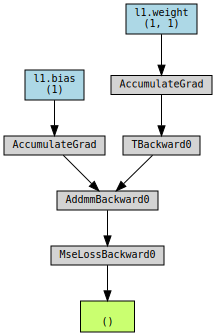

In [48]:
# 코드 5-32: 계산 그래프 시각화

# 손실을 그래프로 나타내기
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [49]:
# 코드 5-33: 경사 계산과 결과 확인

# 경사 계산
loss.backward()

# 경사 계산 결과를 확인
print(net.l1.weight.grad)
print(net.l1.bias.grad)

tensor([[-307.0169]], device='cuda:0')
tensor([-47.3879], device='cuda:0')


In [50]:
# 코드 5-34: 파라미터 수정과 결과 확인

# 파라미터 수정
optimizer.step()

# 수정된 파라미터 확인
print(net.l1.weight)
print(net.l1.bias)

Parameter containing:
tensor([[2.8343]], device='cuda:0', requires_grad=True)
Parameter containing:
tensor([0.7949], device='cuda:0', requires_grad=True)


In [51]:
# 코드 5-35: 경삿값 초기화

# 경삿값 초기화
optimizer.zero_grad()

# 경삿값이 0으로 초기화되었는지 확인
print(net.l1.weight.grad)
print(net.l1.bias.grad)

None
None


### 반복 계산

In [61]:
# 코드 5-36: 초기화 처리

# 학습률
lr = 0.01

# 인스턴스 생성 (학습 시작 전 파라미터 값 초기화)
net = Net(n_input, n_output).to(device)

# 손실 함수: 평균 제곱 오차
criterion = nn.MSELoss()

# 최적화 함수: 경사 하강법
#optimizer = optim.SGD(net.parameters(), lr=lr)
optimizer = optim.AdamW(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 5001

# 평가 결과 기록 (손실 값만 기록)
history = np.zeros((0, 2))

# 코드 5-37: 반복 처리

# 반복 계산 메인 루프
for epoch in range(num_epochs):
    # ① 경삿값 초기화 (가장 먼저 수행!)
    optimizer.zero_grad()

    # ② 예측 계산
    outputs = net(inputs)

    # ③ 손실 계산
    loss = criterion(outputs, labels1)

    # ④ 경사 계산
    loss.backward()

    # ⑤ 파라미터 수정
    optimizer.step()

    # 1000회마다 경과를 기록하고 출력
    if (epoch % 1000 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch {epoch} loss: {loss.item():.5f}')

Epoch 0 loss: 522.08459
Epoch 1000 loss: 60.41766
Epoch 2000 loss: 59.64436
Epoch 3000 loss: 58.40107
Epoch 4000 loss: 56.56783
Epoch 5000 loss: 54.13707


## 5.9 결과 확인

In [54]:
history

array([[   0.    ,  362.4235],
       [1000.    ,   59.8037],
       [2000.    ,   58.8249],
       [3000.    ,   57.2426],
       [4000.    ,   55.0159]])

In [55]:
# 코드 5-38 초기 손실값과 최종 손실값

# 초기 손실값과 최종 손실값
print(f'초기 손실값: {history[0,1]:.5f}')
print(f'최종 손실값: {history[-1,1]:.5f}')

초기 손실값: 362.42349
최종 손실값: 55.01585


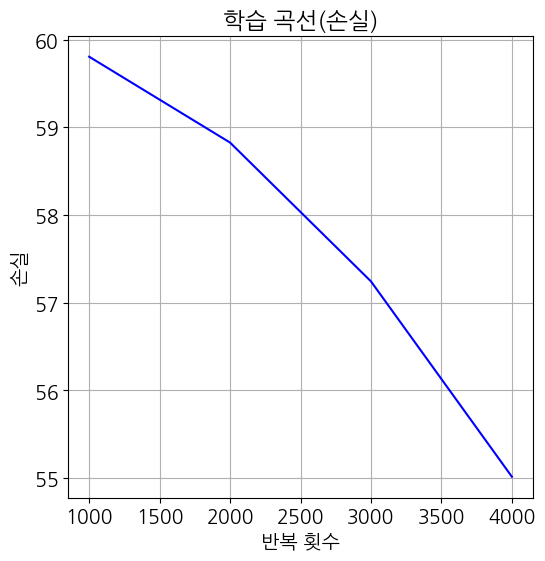

In [56]:
# 코드 5-39 손실 값을 통한 학습 곡선 출력

# 학습 곡선 출력(손실)
# 가장 처음 요소는 제외
import matplotlib.pyplot as plt

plt.plot(history[1:,0], history[1:,1], 'b')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.title('학습 곡선(손실)')
plt.show()

In [57]:
np.array((x.min(), x.max()))

array([3.561, 8.78 ])

In [58]:
np.array((x.min(), x.max())).reshape(-1,1)

array([[3.561],
       [8.78 ]])

In [59]:
# 회귀 직선 산출

# x의 최솟값, 최댓값
xse = np.array((x.min(), x.max())).reshape(-1,1)
Xse = torch.tensor(xse).float().to(device)

with torch.no_grad():
  Yse = net(Xse)

print(Yse.cpu().numpy())

[[ 9.4108]
 [35.0765]]


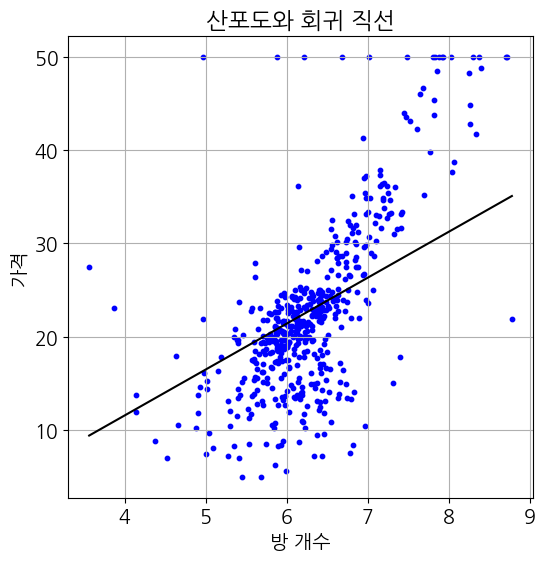

In [60]:
# 코드 5-40 학습 데이터의 산포도와 회귀 직선 출력

# 산포도와 회귀 직선 출력
plt.scatter(x, yt, s=10, c='b')
plt.xlabel('방 개수')
plt.ylabel('가격')
plt.plot(Xse.cpu(), Yse.cpu(), c='k')
plt.title('산포도와 회귀 직선')
plt.show()

## 5.10 중회귀 모델로 확장

In [62]:
# 코드 5-41 입력 변수 x2의 작성

# 열(LSTAT: 저소득자 비율) 추가
x_add = x_org[:, feature_names == 'LSTAT']
x2 = np.hstack((x, x_add))

# shape 표시
print(x2.shape)

# 입력 데이터 x2 표시
print(x2[:5,:])

(506, 2)
[[6.575 4.98 ]
 [6.421 9.14 ]
 [7.185 4.03 ]
 [6.998 2.94 ]
 [7.147 5.33 ]]


In [65]:
# x_org
# x_org[:, feature_names == 'LSTAT']

In [63]:
x2.shape[1]

2

In [66]:
# 코드 5-42 입력 차원수를 2로 하는 모델 인스턴스 재생성
n_input = x2.shape[1]
print(n_input)

# 모델 인스턴스 생성
net = Net(n_input, n_output)

2


In [67]:
# 코드 5-43 named_parameters 함수의 호출

# 모델 안의 파라미터 확인
# predict.weight가 2차원으로 바뀜
for parameter in net.named_parameters():
    print(f'변수명: {parameter[0]}')
    print(f'변숫값: {parameter[1].data}')

변수명: l1.weight
변숫값: tensor([[0.5053, 0.5647]])
변수명: l1.bias
변숫값: tensor([-0.6519])


In [68]:
# 코드 5-44 모델의 개요 표시 1
print(net)

Net(
  (l1): Linear(in_features=2, out_features=1, bias=True)
)


In [69]:
# 코드 5-45 모델의 개요 표시 2
summary(net, (2,))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       3
Total params: 3
Trainable params: 3
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [70]:
# 코드 5-46 입력 변수 inputs 재정의

# 입력 변수 x2를 텐서로 변환
# labels, labels1은 이전과 같음
inputs = torch.tensor(x2).float().to(device)

### 반복 계산

In [71]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [72]:
# 초기화 처리

# 학습률
lr = 0.01

# 인스턴스 생성(파라미터 값 초기화)
net = Net(n_input, n_output)

net = net.to(device)

# 손실 함수：평균 제곱 오차
criterion = nn.MSELoss().to(device)

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 5001

# 평가 결과 기록(손실 값만 기록)
history = np.zeros((0,2))

In [73]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):

    # 경삿값 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 오차 계산
    loss = criterion(outputs, labels1)

    # 경사 계산
    loss.backward()

    # 파라미터 수정
    optimizer.step()

    # 100회 마다 도중 경과를 기록
    if ( epoch % 100 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch {epoch} loss: {loss.item():.5f}')


# loss:nan >> not a number (값이 없음)>> 발산
# 학습률이 커서 nan

Epoch 0 loss: 380.12625
Epoch 100 loss: nan
Epoch 200 loss: nan
Epoch 300 loss: nan
Epoch 400 loss: nan
Epoch 500 loss: nan
Epoch 600 loss: nan
Epoch 700 loss: nan
Epoch 800 loss: nan
Epoch 900 loss: nan
Epoch 1000 loss: nan
Epoch 1100 loss: nan
Epoch 1200 loss: nan
Epoch 1300 loss: nan
Epoch 1400 loss: nan
Epoch 1500 loss: nan
Epoch 1600 loss: nan
Epoch 1700 loss: nan
Epoch 1800 loss: nan
Epoch 1900 loss: nan
Epoch 2000 loss: nan
Epoch 2100 loss: nan
Epoch 2200 loss: nan
Epoch 2300 loss: nan
Epoch 2400 loss: nan
Epoch 2500 loss: nan
Epoch 2600 loss: nan
Epoch 2700 loss: nan
Epoch 2800 loss: nan
Epoch 2900 loss: nan
Epoch 3000 loss: nan
Epoch 3100 loss: nan
Epoch 3200 loss: nan
Epoch 3300 loss: nan
Epoch 3400 loss: nan
Epoch 3500 loss: nan
Epoch 3600 loss: nan
Epoch 3700 loss: nan
Epoch 3800 loss: nan
Epoch 3900 loss: nan
Epoch 4000 loss: nan
Epoch 4100 loss: nan
Epoch 4200 loss: nan
Epoch 4300 loss: nan
Epoch 4400 loss: nan
Epoch 4500 loss: nan
Epoch 4600 loss: nan
Epoch 4700 loss: na

## 5.11 학습률의 변경

In [74]:
# 초기화 처리

# 학습률
lr = 0.001

# 인스턴스 생성(파라미터 값 초기화)
net = Net(n_input, n_output)

net = net.to(device)

# 손실 함수：평균 제곱 오차
criterion = nn.MSELoss().to(device)

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 5000

# 평가 결과 기록(손실 값만 기록)
history = np.zeros((0,2))

In [75]:
# 반복 계산 메인 루프

for epoch in range(num_epochs):

    # 경삿값 초기화
    optimizer.zero_grad()

    # 예측 계산
    outputs = net(inputs)

    # 오차 계산
    loss = criterion(outputs, labels1)

    # 경사 계산
    loss.backward()

    # 파라미터 수정
    optimizer.step()

    # 100회 마다 도중 경과를 기록
    if ( epoch % 100 == 0):
        history = np.vstack((history, np.array([epoch, loss.item()])))
        print(f'Epoch {epoch} loss: {loss.item():.5f}')

Epoch 0 loss: 999.41974
Epoch 100 loss: 33.36230
Epoch 200 loss: 30.56623
Epoch 300 loss: 30.53307
Epoch 400 loss: 30.53263
Epoch 500 loss: 30.53258
Epoch 600 loss: 30.53253
Epoch 700 loss: 30.53248
Epoch 800 loss: 30.53244
Epoch 900 loss: 30.53239
Epoch 1000 loss: 30.53234
Epoch 1100 loss: 30.53229
Epoch 1200 loss: 30.53225
Epoch 1300 loss: 30.53220
Epoch 1400 loss: 30.53215
Epoch 1500 loss: 30.53211
Epoch 1600 loss: 30.53207
Epoch 1700 loss: 30.53202
Epoch 1800 loss: 30.53197
Epoch 1900 loss: 30.53193
Epoch 2000 loss: 30.53188
Epoch 2100 loss: 30.53183
Epoch 2200 loss: 30.53179
Epoch 2300 loss: 30.53174
Epoch 2400 loss: 30.53169
Epoch 2500 loss: 30.53165
Epoch 2600 loss: 30.53161
Epoch 2700 loss: 30.53156
Epoch 2800 loss: 30.53152
Epoch 2900 loss: 30.53147
Epoch 3000 loss: 30.53143
Epoch 3100 loss: 30.53138
Epoch 3200 loss: 30.53133
Epoch 3300 loss: 30.53129
Epoch 3400 loss: 30.53125
Epoch 3500 loss: 30.53120
Epoch 3600 loss: 30.53116
Epoch 3700 loss: 30.53111
Epoch 3800 loss: 30.531

In [76]:
# 코드 5-49 실행 결과 요약

# 초기 손실값, 최종 손실값
print(f'초기 손실값: {history[0,1]:.5f}')
print(f'최종 손실값: {history[-1,1]:.5f}')

초기 손실값: 999.41974
최종 손실값: 30.53059


In [ ]:
# eos